## Predicting Customer Churn in SyriaTel Telecommunications

In [2]:

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings("ignore")

###  1.Overview

In a competitive telecommunications industry customer churn is a big challenge that leads to significant financial losses to companies like SyriaTel.The main obective is to build a binary classifier to predict whether a customer will ("soon") stop doing business with SyriaTel. The ultimate goal is to help in reducing how much money is lost by the company as a result of customers who don't stick around very long by implementing proactive customer retention strategies by identifying patterns in customer behavior and demographic data that may indicate a likelihood that a customer will stop using SyriaTel services.

### 2. Business Understanding
#### 2.1 Project Objectives
#### 2.1.1 Main Objective
To develop the best model to predict customer churn for SyriaTel, aiming to reduce the financial impact of churn by implementing proactive retention strategies.

### 2.1.2 Specific Objectives



### 2.2 Success Measurement



### 2.3 Stakeholders
SyriaTel Management

Customer retention team

Finance Department

Marketing Team








### 3. Data Understanding

#### 3.1 Data Source
The dataset used  was obtained from Kaggle and consists of 21 columns and 3333 rows. It contains information relevant to predicting customer churn for SyriaTel, a telecommunications company. Each row represents a customer, and each column represents a specific feature or attribute related to customer behavior, demographics, and interactions with SyriaTel's services.


#### 3.2 Intergration 

### 4. Data Preparation

### 4.1  Load Dataset



In [14]:
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")
df_copy = df.copy()
df_copy.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [15]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

Our dataset has a total of 3333 row and 21 columns with a clear indication of no missing values in the dataset

In [ ]:

df_copy.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


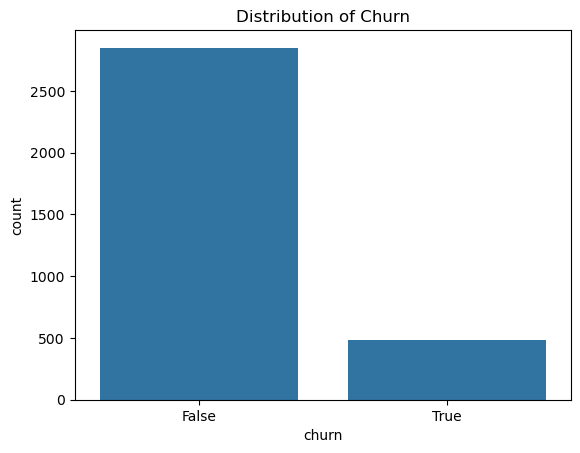

churn
False    2850
True      483
Name: count, dtype: int64


In [21]:
#Checking for class imbalance in the target variable 'churn'
sns.countplot(x='churn', data=df_copy)
plt.title('Distribution of Churn')
plt.show()
print(df_copy['churn'].value_counts())

The target variable churn indicates that out of the reported 3333 customers,a total 2850 customers did not stop using SyriaTel whereas a total 483 customers stopped using SyriaTel. This indicates that the dataset is moderately imbalanced, with approximately 14.5% of customers stopped using the SyriaTel services.